# Building a room with Librosa 

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pyroomacoustics as pra
from IPython import display
from megamicros_ailab.antenna import Antenna, BmfAntenna, Mu32_Mems32_JetsonNano_0001
from megamicros_ailab.room import arrange_2D
from megamicros_ailab.bmf import BeamformerDas2D
from megamicros_aidb.query.db import AidbSession
from megamicros.data import MuAudio
from megamicros.log import log
from megamicros.audio import generate_moovie
from megamicros.core_base import MU_MEMS_SENSIBILITY


log.setLevel( "INFO" )

FRAME_LENGTH = 1024
SAMPLING_FREQUENCY = 10000
ROOM_SIZE = (8.40, 10.2, 2.05)          # 6 box + 1 couloir + 6 box + 6 box   
ANTENNA_POSITION = (2.95, 5.1, 2.03)    # au centre du couloir face aux cases 432, 433, 434, 435 et 422, 424, 426 et 428
SPACE_SAMPLING = (4, 4)
SOURCE_POSITION = (3.5, 6, 0.5)
SPACE_SAMPLING = (4, 4)

LABEL_ID = 15 # piglet-squeals
SELECTED = 0

### Import the signal

In [5]:
# Get signal mesure from database
# Mesure label is 19

with AidbSession(
    dbhost='http://dbwelfare.biimea.io/',
    login='ailab',
    email='bruno.gas@biimea.com',
    password='#T;uZnQ5UJ_JC~&' ) as session:
        label_id = LABEL_ID
        labelings_file = session.load_labelings( label_id=label_id )
        print( f"Etiquettages trouvés:" )
        for labeling_file in labelings_file:
            print( f" > [{labeling_file['sourcefile_id']}: {labeling_file['sourcefile_filename']}]")
        sourcefile_id = int( input( 'Numéro identificateur du fichier à sélectionner:' ) )
        limit = 100
        channels = list( np.arange( 32 ) + 1 )
        signals = session.load_labelized( sourcefile_id=sourcefile_id, label_id=label_id, limit=limit, channels=channels )
        
print( f"{len(signals)} section audio récupérées: " )
for idx, aud in enumerate( signals ):
    print( f"Audio[{idx}]: {aud} -> label={aud.label}, channels number: {aud.channels_number} ({aud.samples_number} samples)")

2023-08-07 15:17:09,895 [INFO]:  .Try connecting on endpoint database http://dbwelfare.biimea.io/...
2023-08-07 15:17:10,252 [INFO]:  .Got HTTP 200 status code from server
2023-08-07 15:17:10,254 [INFO]:  .Received CSRF token: uJ5eaHnQtQk0I95KV87sjxJkACfrDuZR. Update session with
2023-08-07 15:17:10,256 [INFO]:  .Received session id: z2g0tde5imp4b8bw906i9qyt083wcarn
2023-08-07 15:17:10,257 [INFO]:  .Successfully connected on http://dbwelfare.biimea.io/
2023-08-07 15:17:10,259 [INFO]:  .Downloading labelings from http://dbwelfare.biimea.io/...
2023-08-07 15:17:10,431 [INFO]:  .Received 29 labelings


Etiquettages trouvés:
 > [6830: mu5h-20220722-003849.h5]
 > [8146: mu5h-20220720-000540.h5]
 > [8146: mu5h-20220720-000540.h5]
 > [8146: mu5h-20220720-000540.h5]
 > [8146: mu5h-20220720-000540.h5]
 > [8146: mu5h-20220720-000540.h5]
 > [8146: mu5h-20220720-000540.h5]
 > [8146: mu5h-20220720-000540.h5]
 > [8146: mu5h-20220720-000540.h5]
 > [8146: mu5h-20220720-000540.h5]
 > [8146: mu5h-20220720-000540.h5]
 > [8146: mu5h-20220720-000540.h5]
 > [8146: mu5h-20220720-000540.h5]
 > [8146: mu5h-20220720-000540.h5]
 > [8146: mu5h-20220720-000540.h5]
 > [8289: mu5h-20220719-230445.h5]
 > [8289: mu5h-20220719-230445.h5]
 > [8289: mu5h-20220719-230445.h5]
 > [8289: mu5h-20220719-230445.h5]
 > [7149: mu5h-20220719-213305.h5]
 > [6831: mu5h-20220719-191605.h5]
 > [6560: mu5h-20220719-174529.h5]
 > [6560: mu5h-20220719-174529.h5]
 > [6560: mu5h-20220719-174529.h5]
 > [7728: mu5h-20220719-173006.h5]
 > [7728: mu5h-20220719-173006.h5]
 > [7728: mu5h-20220719-173006.h5]
 > [4559: mu5h-20220722-002022.h5

Numéro identificateur du fichier à sélectionner: 4559


2023-08-07 15:17:26,650 [INFO]:  .Downloading labelized audio files from http://dbwelfare.biimea.io/...
2023-08-07 15:17:26,706 [INFO]:  .Found 1 labelized audio files
2023-08-07 15:17:26,709 [INFO]:  .Limit is set to 100 audio files
2023-08-07 15:17:26,710 [INFO]:  .Downloading metadata for object 'sourcefile' [4559]...
2023-08-07 15:17:26,806 [INFO]:  Object sourcefile found with identifier [4559] 
2023-08-07 15:17:36,066 [INFO]:  .Trying to disconnect from database http://dbwelfare.biimea.io/...
2023-08-07 15:17:36,118 [INFO]:  .Logout successful.


I'm a NDarray signal with frame size = 116743 and frame number = 1
1 section audio récupérées: 
Audio[0]: 32 X 116743 audio signals (sf=10000.0 Hz) -> label=piglet-squeals, channels number: 32 (116743 samples)


In [13]:
# Select a signal
#selected = int( input( f"Choisir un signal (0 à {len(signals)-1}): " ) )
selected = SELECTED
antenna_output: MuAudio = signals[selected]
signal = antenna_output.channel(0)

In [7]:
# Play original sound
left = np.array( antenna_output.channel(0) )
right = np.array( antenna_output.channel(1) )
sound = np.array( [left, right] )
display.Audio(sound, rate=SAMPLING_FREQUENCY )

In [ ]:
from scipy.io import wavfile
_, signal = wavfile.read("../guitar_16k.wav")

print( np.shape(signal) )

In [ ]:
ff = 1000
N = 16384
signal = np.cos(2*np.pi*ff*np.arange(N)/SAMPLING_FREQUENCY)

### Build the room
Desired reverberation time and dimensions of the room

In [8]:
rt60_tgt = 0.3  # seconds
room_dim = ROOM_SIZE  # meters

We invert Sabine's formula to obtain the parameters for the ISM simulator

In [9]:
e_absorption, max_order = pra.inverse_sabine(rt60_tgt, room_dim)

Create the room

In [10]:
room = pra.ShoeBox(
    room_dim, 
    fs=SAMPLING_FREQUENCY, 
    materials=pra.Material(e_absorption), 
    max_order=max_order,
    use_rand_ism = True, 
    max_rand_disp = 0.05
)

#room = pra.ShoeBox(
#    room_dim, 
#    fs=SAMPLING_FREQUENCY
#)

### Build the antenna


In [11]:
antenna_square: Antenna = Mu32_Mems32_JetsonNano_0001
antenna_square.set_position( ANTENNA_POSITION )

Locate the antenna in the room

In [12]:
Lg_t = 0.100                # filter size in seconds
Lg = np.ceil(Lg_t*SAMPLING_FREQUENCY)       # in samples
mics = pra.Beamformer( antenna_square.mems().T, room.fs, N=FRAME_LENGTH, Lg=Lg)
room.add_microphone_array( mics )

### Compute antenna response

In [14]:
room.add_source( SOURCE_POSITION, signal=signal, delay=1.3 )

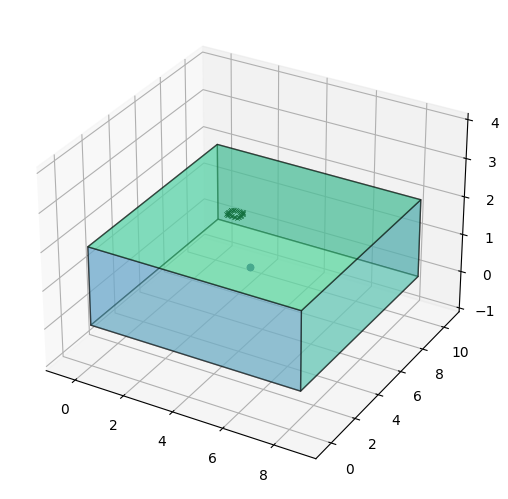

In [15]:
fig, ax = room.plot()
ax.set_xlim([-1, ROOM_SIZE[0]+1])
ax.set_ylim([-1, ROOM_SIZE[1]+1]);
ax.set_zlim([-1, ROOM_SIZE[2]+2]);

In [16]:
# Compute DAS weights
mics.rake_delay_and_sum_weights(room.sources[0][:1])

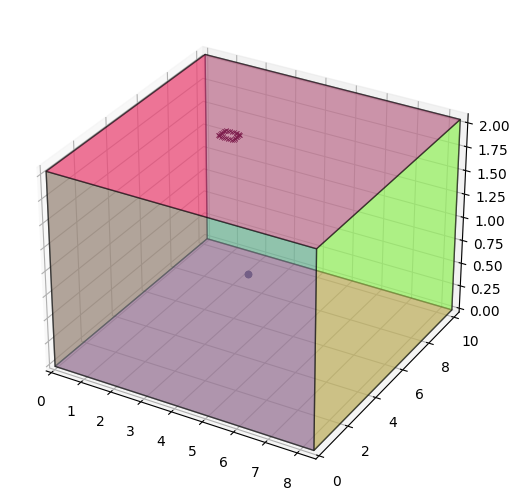

In [17]:
fig, ax = room.plot(freq=[500, 1000, 2000, 4000], img_order=0)

In [18]:
room.simulate()

### Show results

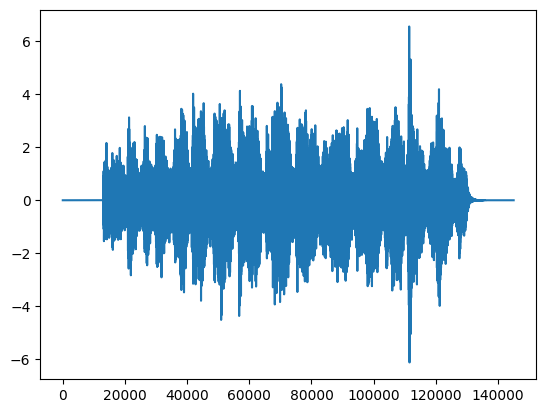

In [19]:
plt.plot(room.mic_array.signals[0,:])
plt.show()

In [20]:
display.Audio(signal, rate=SAMPLING_FREQUENCY )

Select 0 ans 1 mems of the beam F0. The source should be comming from the left

In [21]:
display.Audio([room.mic_array.signals[0,:], room.mic_array.signals[1,:]], rate=SAMPLING_FREQUENCY )

Select 0 ans 1 mems of the beam F2, that is 16 and 17th mems. Because of the position/orientation of the antenna, the source should be comming from the right:

In [22]:
display.Audio([room.mic_array.signals[16,:], room.mic_array.signals[17,:]], rate=SAMPLING_FREQUENCY )

In [23]:
signal_das = mics.process(FD=False)
print("DAS Beamformed Signal:")
display.display( display.Audio(signal_das, rate=SAMPLING_FREQUENCY) )

DAS Beamformed Signal:


### Compute the delay and sum weights for the beamformer

In [25]:
# Space quantization
sq_x = SPACE_SAMPLING[0]
sq_y = SPACE_SAMPLING[1]
nx: int = int( ROOM_SIZE[0] * sq_x )
ny: int = int( ROOM_SIZE[1] * sq_y )
ground_elevation = 0.20
space_q = arrange_2D( ROOM_SIZE, sq_x=sq_x, sq_y=sq_y, ground_elevation=ground_elevation )
space_q_2D = np.reshape( space_q, (nx, ny, 3) )

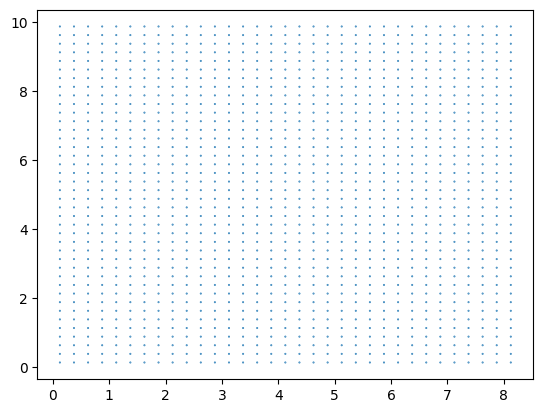

In [26]:
plt.scatter(space_q[:,0], space_q[:,1], space_q[:,2] )
plt.show()

In [29]:
# Create antenna with beamformer
bmf_antenna: BmfAntenna = BmfAntenna( 
    mems = Mu32_Mems32_JetsonNano_0001.mems(),
    position = ANTENNA_POSITION,
    frame_length = FRAME_LENGTH,
    space_q = space_q,
    sampling_frequency = SAMPLING_FREQUENCY
)

2023-08-07 15:27:44,145 [INFO]:  .Build antenna with 32 MEMs at position [2.95 5.1  2.03]
2023-08-07 15:27:44,148 [INFO]:  .Buffered antenna set with frames of length 1024 samples
2023-08-07 15:27:44,149 [INFO]:  .Beamformer2D Initilization:
2023-08-07 15:27:44,150 [INFO]:   > Found antenna with 32 mems microphones at position [2.95 5.1  2.03]
2023-08-07 15:27:44,150 [INFO]:   > Frame length is 1024
2023-08-07 15:27:44,152 [INFO]:   > Time range: [0, 0.1023] s
2023-08-07 15:27:44,153 [INFO]:   > Frequency range: [0, 5000.0] Hz (513 beams)
2023-08-07 15:27:44,153 [INFO]:   > Space quantization: 1320 locations requested
2023-08-07 15:27:44,154 [INFO]:   > Build distances matrix D (1320 x 32)
2023-08-07 15:27:44,256 [INFO]:   > Build preformed channels matrix H (513 x 1320 x 32)


In [31]:
bmf_antenna.set_data( room.mic_array.signals )

In [32]:
# Comput BMF
BF: np.ndarray = np.zeros( (len(space_q),) )
E = []
imgs = []
for bf in bmf_antenna:
    E.append( np.sum( bf ) )
    BF += bf
    imgs.append( np.reshape( bf, (nx, ny) ).T )

2023-08-07 15:31:30,481 [INFO]:  .Create ./tmp directory...
2023-08-07 15:31:30,506 [INFO]:  .Generate images as png files without normalization...
2023-08-07 15:32:19,233 [INFO]:  .Generate video from png files...
2023-08-07 15:32:19,907 [INFO]:  .Generate sound wav file...
2023-08-07 15:32:19,908 [INFO]:  .Merge audio with video and make mp4 movie file...
2023-08-07 15:32:20,089 [INFO]:  .Movie saved


audio saved


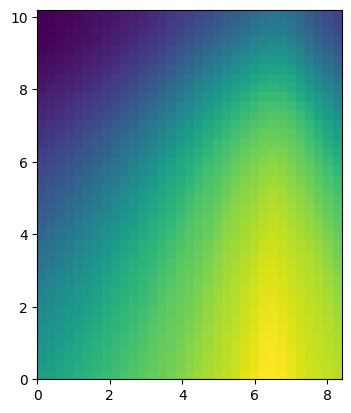

In [35]:
generate_moovie( 
    imgs, 
    rate=SAMPLING_FREQUENCY/FRAME_LENGTH, 
    sound=sound.astype( np.float32 ).T, 
    sampling_frequency=SAMPLING_FREQUENCY,
    norm=None,
    extent=( 0, ROOM_SIZE[0], 0, ROOM_SIZE[1] )
)